# OU process - Work sheet - Pridict $S_\theta$
## OU process basic information
Consider the OU process

$$
dx_t = -\beta x_t dt + \sigma dW_t, \quad x(0) \sim p_0(x_0).
$$

The solution is

$$
x_t = \mu_t(x_0) + \sigma_t \epsilon, \quad \epsilon \sim \mathcal{N}(0, 1),
$$

where

$$
\mu_t(x_0) = e^{-\beta t} x_0, \quad \sigma_t^2 = \frac{\sigma^2}{2\beta}(1 - e^{-2\beta t}).
$$

So, given a terminal time $T$, we can generate $x_t$, for $t \in [0, T]$.

# 1. Dataset and Training

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 2048

def sample_line(n_points):
    slope = 0.4
    intercept = -5.0
    x = np.random.uniform(-6, 6, size=n_points)
    noise = np.random.randn(n_points) * 0.2   
    y = slope * x + intercept + noise
    return np.stack([x, y], axis=1)

def sample_blob(n_points):
    mu = np.array([4, 5])
    C = np.eye(2) * 1.0
    return mu + np.random.multivariate_normal([0,0], C, size=n_points)

def sample_p0_mix(n_blob=3000, n_line=2000):
    blob = sample_blob(n_blob)
    line = sample_line(n_line)
    data = np.concatenate([blob, line], axis=0)
    np.random.shuffle(data)
    return data

def marginal_prob_std(t, beta_min=0.1, beta_max=20.0):
    log_mean_coeff = -0.25 * t ** 2 * (beta_max - beta_min) - 0.5 * t * beta_min
    mean = torch.exp(log_mean_coeff)
    std = torch.sqrt(1. - torch.exp(2. * log_mean_coeff))
    return mean, std

def get_beta_schedule(t, beta_min=0.1, beta_max=20.0):
    """
    計算時間 t 當下的噪聲係數 beta(t)。
    這對應到 VP-SDE 中的線性噪聲排程。
    """
    return beta_min + t * (beta_max - beta_min)

In [ ]:
class GaussianFourierProjection(nn.Module):
    def __init__(self, embed_dim, scale=30.):
        super().__init__()
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)
    def forward(self, x):
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class ScoreNet_SDE(nn.Module):
    def __init__(self, x_dim, hidden):
        super().__init__()
        self.embed = nn.Sequential(
            GaussianFourierProjection(embed_dim=hidden),
            nn.Linear(hidden, hidden),
            nn.SiLU()
        )
        self.fc1 = nn.Linear(x_dim, hidden)
        self.layers = nn.ModuleList()
        for _ in range(3):
            self.layers.append(nn.Linear(hidden, hidden))
        self.fc_out = nn.Linear(hidden, x_dim)
        self.act = nn.SiLU()

    def forward(self, x, t):
        _, std = marginal_prob_std(t)
        std = std.view(-1, 1)

        t_embed = self.embed(t)
        h = self.fc1(x)
        h = h + t_embed
        h = self.act(h)
        for layer in self.layers:
            h = self.act(layer(h)) 
        
        h = self.fc_out(h)
        
        # Output: Score    <<<<<<<<<<<<<<<<<<<<<<<<<
        return h / std

def sde_score_matching_loss(model, x0):
    batch_size = x0.shape[0]
    t = torch.rand(batch_size, device=x0.device) * (1. - 1e-3) + 1e-3
    
    mean, std = marginal_prob_std(t)
    mean = mean.view(-1, 1)
    std = std.view(-1, 1)
    
    noise = torch.randn_like(x0) 
    xt = mean * x0 + std * noise
    
    score_pred = model(xt, t)
    
    # -(Xt - mean*X0) / var = -noise / std
    score_target = -noise / std
    
    losses = torch.sum((score_pred - score_target)**2, dim=1)
    loss = torch.mean(losses * (std ** 2))
    
    return loss

In [15]:
# =========== Training Loop ===========
model = ScoreNet_SDE(x_dim=2, hidden=128).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("Start SDE Training...")
n_step = 5000
loss_history = []

for step in range(1, n_step+1):
    x0_np = sample_p0_mix(batch_size//2, batch_size - batch_size//2).astype(np.float32)
    x0 = torch.from_numpy(x0_np).to(device)
    
    model.train()
    loss = sde_score_matching_loss(model, x0)
    
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    
    loss_history.append(loss.item())
    if step % 500 == 0:
        print(f"Step {step:4d} | Loss: {loss.item():.6f}")


Start SDE Training...
Step  500 | Loss: 40.167320
Step 1000 | Loss: 55.448792
Step 1500 | Loss: 42.854832
Step 2000 | Loss: 30.528831
Step 2500 | Loss: 30.529745
Step 3000 | Loss: 37.897270
Step 3500 | Loss: 23.947760
Step 4000 | Loss: 17.434444
Step 4500 | Loss: 64.436409
Step 5000 | Loss: 26.832703


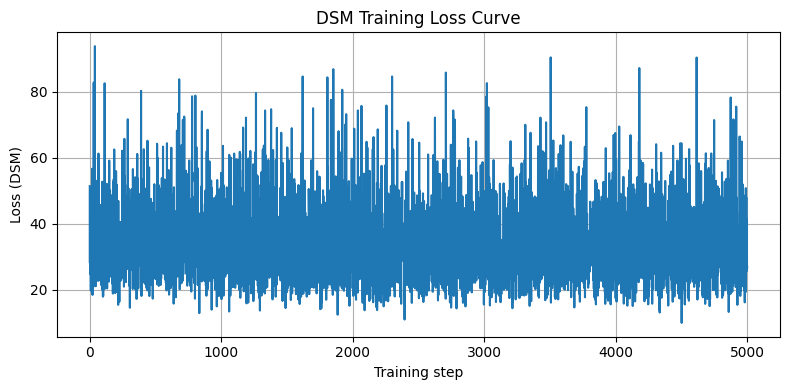

In [16]:
import matplotlib.pyplot as plt

def plot_loss_curve(loss_list):
    """
    loss_list: Python list or Tensor containing loss values for each step
    """
    plt.figure(figsize=(8,4))
    plt.plot(loss_list, linewidth=1.5)
    plt.xlabel("Training step")
    plt.ylabel("Loss (DSM)")
    plt.title("DSM Training Loss Curve")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_loss_curve(loss_history)

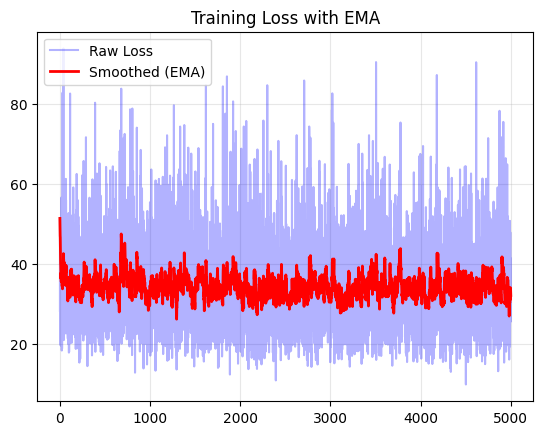

In [ ]:
def plot_smooth_loss(loss_history, alpha=0.9):
    smooth_loss = []
    current_avg = loss_history[0]
    for val in loss_history:
        current_avg = alpha * current_avg + (1 - alpha) * val
        smooth_loss.append(current_avg)
    
    plt.plot(loss_history, alpha=0.3, color='blue', label='Raw Loss')
    plt.plot(smooth_loss, color='red', linewidth=2, label='Smoothed (EMA)')
    plt.title("Training Loss with EMA")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_smooth_loss(loss_history)

# 2. Sampling(Reverse)

In [ ]:
@torch.no_grad()
def p_sample_loop(model, shape, n_steps=1000):
    device = next(model.parameters()).device
    x = torch.randn(shape, device=device)
    time_steps = torch.linspace(1., 1e-3, n_steps + 1, device=device)
    
    for i in range(n_steps):
        t_current = time_steps[i]
        dt = t_current - time_steps[i+1]
        
        beta_t = get_beta_schedule(t_current)
        batch_t = torch.ones(shape[0], device=device) * t_current
        
        score = model(x, batch_t)
        
        drift = (-0.5 * beta_t * x - beta_t * score) * (-dt)
        diffusion = torch.sqrt(beta_t) * torch.sqrt(dt) * torch.randn_like(x)
        x = x + drift + diffusion
        
    return x.cpu().numpy()

Sampling...


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


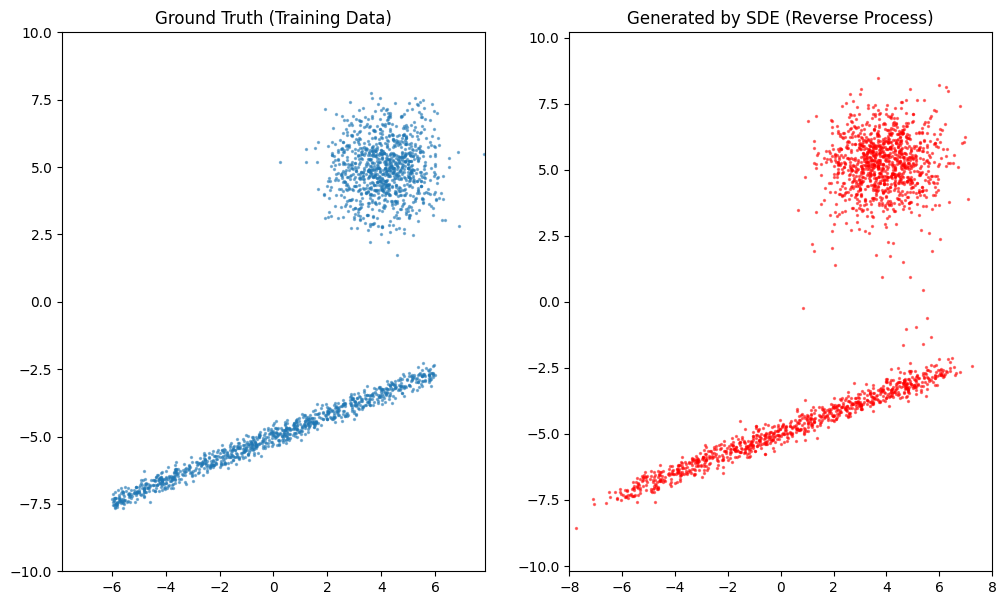

In [ ]:
# --- 執行採樣並畫圖 (Gemini)---
print("Sampling...")
model.eval() # 切換到評估模式

# 生成 2000 個點
samples = p_sample_loop(model, shape=(2000, 2), n_steps=1000)

# 畫圖比較
plt.figure(figsize=(12, 7))

# 左邊：真實數據
plt.subplot(1, 2, 1)
real_data = sample_p0_mix(1000, 1000)
plt.scatter(real_data[:,0], real_data[:,1], s=2, alpha=0.5, label='Real Data')
plt.title("Ground Truth (Training Data)")
plt.axis('equal')
plt.xlim(-8, 8); plt.ylim(-10, 10)

# 右邊：生成數據
plt.subplot(1, 2, 2)
plt.scatter(samples[:,0], samples[:,1], s=2, alpha=0.5, c='red', label='Generated')
plt.title("Generated by SDE (Reverse Process)")
plt.axis('equal')
plt.xlim(-8, 8); plt.ylim(-10, 10)

plt.show()

Sampling with inspection...


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


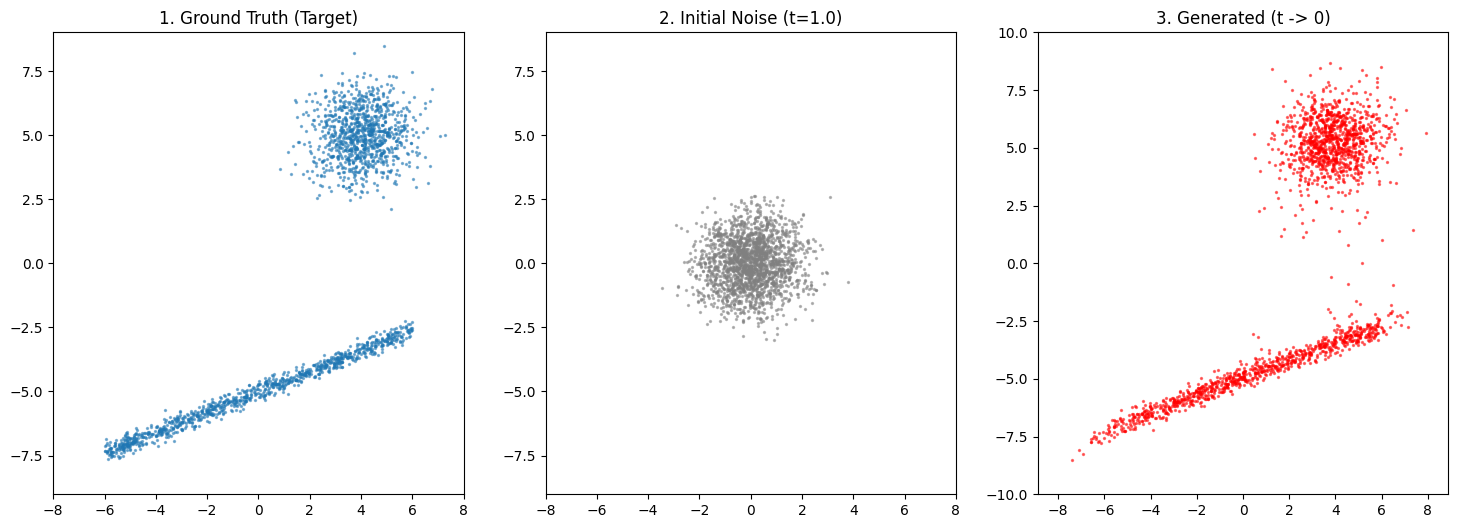

In [19]:
@torch.no_grad()
def p_sample_loop_inspect(model, shape, n_steps=1000):
    device = next(model.parameters()).device
    
    # 1. 這是起點：從標準常態分佈採樣 (Pure Noise)
    x_init = torch.randn(shape, device=device)
    x = x_init.clone() # 複製一份，讓 x_init 保持原樣回傳
    
    time_steps = torch.linspace(1., 1e-3, n_steps + 1, device=device)
    
    for i in range(n_steps):
        t_current = time_steps[i]
        dt = t_current - time_steps[i+1]
        
        beta_t = get_beta_schedule(t_current)
        batch_t = torch.ones(shape[0], device=device) * t_current
        
        # 使用模型預測 Score
        score = model(x, batch_t)
        
        # SDE Update
        drift = (-0.5 * beta_t * x - beta_t * score) * (-dt)
        diffusion = torch.sqrt(beta_t) * torch.sqrt(dt) * torch.randn_like(x)
        x = x + drift + diffusion
        
    return x_init.cpu().numpy(), x.cpu().numpy()

# --- 執行採樣並畫三張圖 ---
print("Sampling with inspection...")
model.eval()

# 取得 初始雜訊 與 生成結果
x_start, x_end = p_sample_loop_inspect(model, shape=(2000, 2), n_steps=1000)

plt.figure(figsize=(18, 6)) # 加寬畫布

# 1. 真實數據 (Ground Truth)
plt.subplot(1, 3, 1)
real_data = sample_p0_mix(1000, 1000)
plt.scatter(real_data[:,0], real_data[:,1], s=2, alpha=0.5, label='Real Data')
plt.title("1. Ground Truth (Target)")
plt.axis('equal'); plt.xlim(-8, 8); plt.ylim(-10, 10)

# 2. 初始狀態 (Initial Noise) - 這就是你想看的！
plt.subplot(1, 3, 2)
plt.scatter(x_start[:,0], x_start[:,1], s=2, alpha=0.5, c='gray', label='Initial Noise')
plt.title("2. Initial Noise (t=1.0)")
plt.axis('equal'); plt.xlim(-8, 8); plt.ylim(-10, 10)

# 3. 生成結果 (Generated)
plt.subplot(1, 3, 3)
plt.scatter(x_end[:,0], x_end[:,1], s=2, alpha=0.5, c='red', label='Generated')
plt.title("3. Generated (t -> 0)")
plt.axis('equal'); plt.xlim(-8, 8); plt.ylim(-10, 10)

plt.show()

In [21]:
def mmd_score(x, y, sigma=1.0):
    """
    x: real data (N, 2)
    y: generated data (M, 2)
    sigma: kernel bandwidth
    """
    # 1. 統一轉成 Tensor
    if not isinstance(x, torch.Tensor):
        x = torch.tensor(x)
    if not isinstance(y, torch.Tensor):
        y = torch.tensor(y)
        
    # 2. 【關鍵修正】強制轉成 float32 以避免 double != float 錯誤
    x = x.float()
    y = y.float()
    
    # 計算 Gaussian Kernel: k(x,y) = exp(-||x-y||^2 / (2*sigma^2))
    def gaussian_kernel(a, b):
        dist = torch.cdist(a, b, p=2)**2
        return torch.exp(-dist / (2 * sigma**2))

    xx = gaussian_kernel(x, x)
    yy = gaussian_kernel(y, y)
    xy = gaussian_kernel(x, y)
    
    return (xx.mean() + yy.mean() - 2 * xy.mean()).item()

# 1. 準備數據
real_data = sample_p0_mix(2000, 2000) # (4000, 2)
generated_data = samples              # (2000, 2) 從 p_sample_loop 跑出來的

# 為了計算公平，取相同數量
min_len = min(len(real_data), len(generated_data))
real_sample = real_data[:min_len]
fake_sample = generated_data[:min_len]

print("--- Quantitative Evaluation ---")

# Test 1: MMD (數值越小越好)
mmd = mmd_score(torch.tensor(real_sample), torch.tensor(fake_sample), sigma=2.0)
print(f"1. MMD Score: {mmd:.5f} (越接近 0 越好)")

--- Quantitative Evaluation ---
1. MMD Score: 0.00422 (越接近 0 越好)
